In [2]:
!pip install ultralytics

In [3]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [6]:
from google.colab import files

uploaded = files.upload()

Saving AgroFarmer.v1i.folder.zip to AgroFarmer.v1i.folder.zip


In [7]:
!unzip AgroFarmer.v1i.folder.zip

Streaming output truncated to the last 5000 lines.
 extracting: test/brown_spot/brown_spot772_jpg.rf.5056a21896e8c00a175aa6bfde1eea1c.jpg  
 extracting: test/bacterial_leaf_blight/bacterial_leaf_blight727_jpg.rf.3b85ec0c79c111920e80367bef680499.jpg  
 extracting: test/healthy/healthy228_jpg.rf.4a9ab27eb28bffe631f3752b8e178b82.jpg  
 extracting: test/leaf_blast/leaf_blast1689_jpg.rf.97061234f3b1401fd6472abf5a24e2d5.jpg  
 extracting: train/narrow_brown_spot/narrow_brown_spot1250_jpg.rf.47efadcc442931a20419d0d24c75dd15.jpg  
 extracting: train/rice_hispa/rice_hispa202_jpg.rf.e42e1537182bedef9545a5f094e61561.jpg  
 extracting: train/sheath_blight/sheath_blight119_jpg.rf.737c6be834b0d177529f962152d50422.jpg  
 extracting: train/healthy/healthy41_jpg.rf.be33302c7289267612e4c01e1f1fc334.jpg  
 extracting: train/leaf_blast/leaf_blast1390_jpg.rf.5ce89773267db92ce64911af6da3ae2a.jpg  
 extracting: train/narrow_brown_spot/narrow_brown_spot702_jpg.rf.3749290db75f108c6374c69a65d5a60b.jpg  
 extrac

In [9]:
!ls

AgroFarmer.v1i.folder.zip  README.roboflow.txt	test   valid
README.dataset.txt	   sample_data		train


In [11]:
!ls train

bacterial_leaf_blight  healthy	   leaf_scald	      neck_blast  sheath_blight
brown_spot	       leaf_blast  narrow_brown_spot  rice_hispa  tungro


In [12]:
!pwd
!ls /content

/content
AgroFarmer.v1i.folder.zip  README.roboflow.txt	test   valid
README.dataset.txt	   sample_data		train


valid → val rename — this is important: YOLOv8's classification trainer specifically looks for a folder named val, not valid. Roboflow exports as valid, so without this fix, training would fail to find your validation set. The script auto-renames it safely.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Dataset already unzipped directly into /content (train/valid/test sit here)
DATASET_DIR = "/content"

# IMPORTANT: YOLOv8 classification trainer expects a folder named "val",
# but Roboflow exports it as "valid". Rename it (safe to run multiple times).
if os.path.exists(os.path.join(DATASET_DIR, "valid")) and not os.path.exists(os.path.join(DATASET_DIR, "val")):
    os.rename(os.path.join(DATASET_DIR, "valid"), os.path.join(DATASET_DIR, "val"))

# Sanity check folder structure
print(os.listdir(DATASET_DIR))
print(os.listdir(os.path.join(DATASET_DIR, "train")))
print(os.listdir(os.path.join(DATASET_DIR, "val")))


Mounted at /content/drive
['.config', 'test', 'drive', 'val', 'train', 'README.roboflow.txt', 'README.dataset.txt', 'AgroFarmer.v1i.folder.zip', 'sample_data']
['tungro', 'bacterial_leaf_blight', 'rice_hispa', 'leaf_blast', 'healthy', 'leaf_scald', 'brown_spot', 'sheath_blight', 'narrow_brown_spot', 'neck_blast']
['tungro', 'bacterial_leaf_blight', 'rice_hispa', 'leaf_blast', 'healthy', 'leaf_scald', 'brown_spot', 'sheath_blight', 'narrow_brown_spot', 'neck_blast']


**Training of the model**

In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")  # nano backbone — fast, good baseline for 10.5k images

results = model.train(
    data=DATASET_DIR,
    epochs=60,              # 10.5k images, 10 classes -> 60 is enough with early stopping
    imgsz=224,              # standard for cls models, good balance of speed/accuracy
    batch=64,                # T4 (15GB) handles this fine for cls at imgsz=224; drop to 32 if OOM
    patience=15,             # stop if val accuracy doesn't improve for 15 epochs
    optimizer="AdamW",       # generally converges faster/more stably than SGD for cls
    lr0=0.001,                # initial learning rate, good default for AdamW + cls head
    cos_lr=True,              # cosine LR decay — smoother convergence than step decay
    dropout=0.2,               # mild regularization, helps with 10-class confusion (similar diseases)
    label_smoothing=0.1,        # helps when classes are visually close (disease vs disease)
    seed=42,                     # reproducibility
    project="rice_disease_cls",
    name="v1",
    exist_ok=True,                # allows re-running without folder conflict
    verbose=True,
    plots=True                      # saves accuracy/loss curves, confusion matrix
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze

**Training Done**

In [15]:
!ls /content/runs/classify/rice_disease_cls/v1/weights/

best.pt  last.pt


**Validate**

In [16]:
metrics = model.val()
print(f"Top-1 Accuracy: {metrics.top1:.4f}")
print(f"Top-5 Accuracy: {metrics.top5:.4f}")


Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/train... found 10516 images in 10 classes ✅ 
val: /content/val... found 3005 images in 10 classes ✅ 
test: /content/test... found 1502 images in 10 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 237.1±108.3 MB/s, size: 3.9 KB)
val: Scanning /content/val... 3005 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3005/3005 741.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 188/188 24.8it/s 7.6s
                   all      0.996          1
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Top-1 Accuracy: 0.9960
Top-5 Accuracy: 1.0000


**Test**

In [19]:
test_metrics = model.val(data=DATASET_DIR, split="test")
print(f"Test Top-1 Accuracy: {test_metrics.top1:.4f}")
print(f"Test Top-5 Accuracy: {test_metrics.top5:.4f}")

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/train... found 10516 images in 10 classes ✅ 
val: /content/val... found 3005 images in 10 classes ✅ 
test: /content/test... found 1502 images in 10 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 144.5±80.3 MB/s, size: 4.4 KB)
test: Scanning /content/test... 1502 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1502/1502 2.7Kit/s 0.6s
test: New cache created: /content/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 94/94 29.0it/s 3.2s
                   all      0.994          1
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-2
Test Top-1 Accuracy: 0.9940
Test Top-5 Accuracy: 1.0000


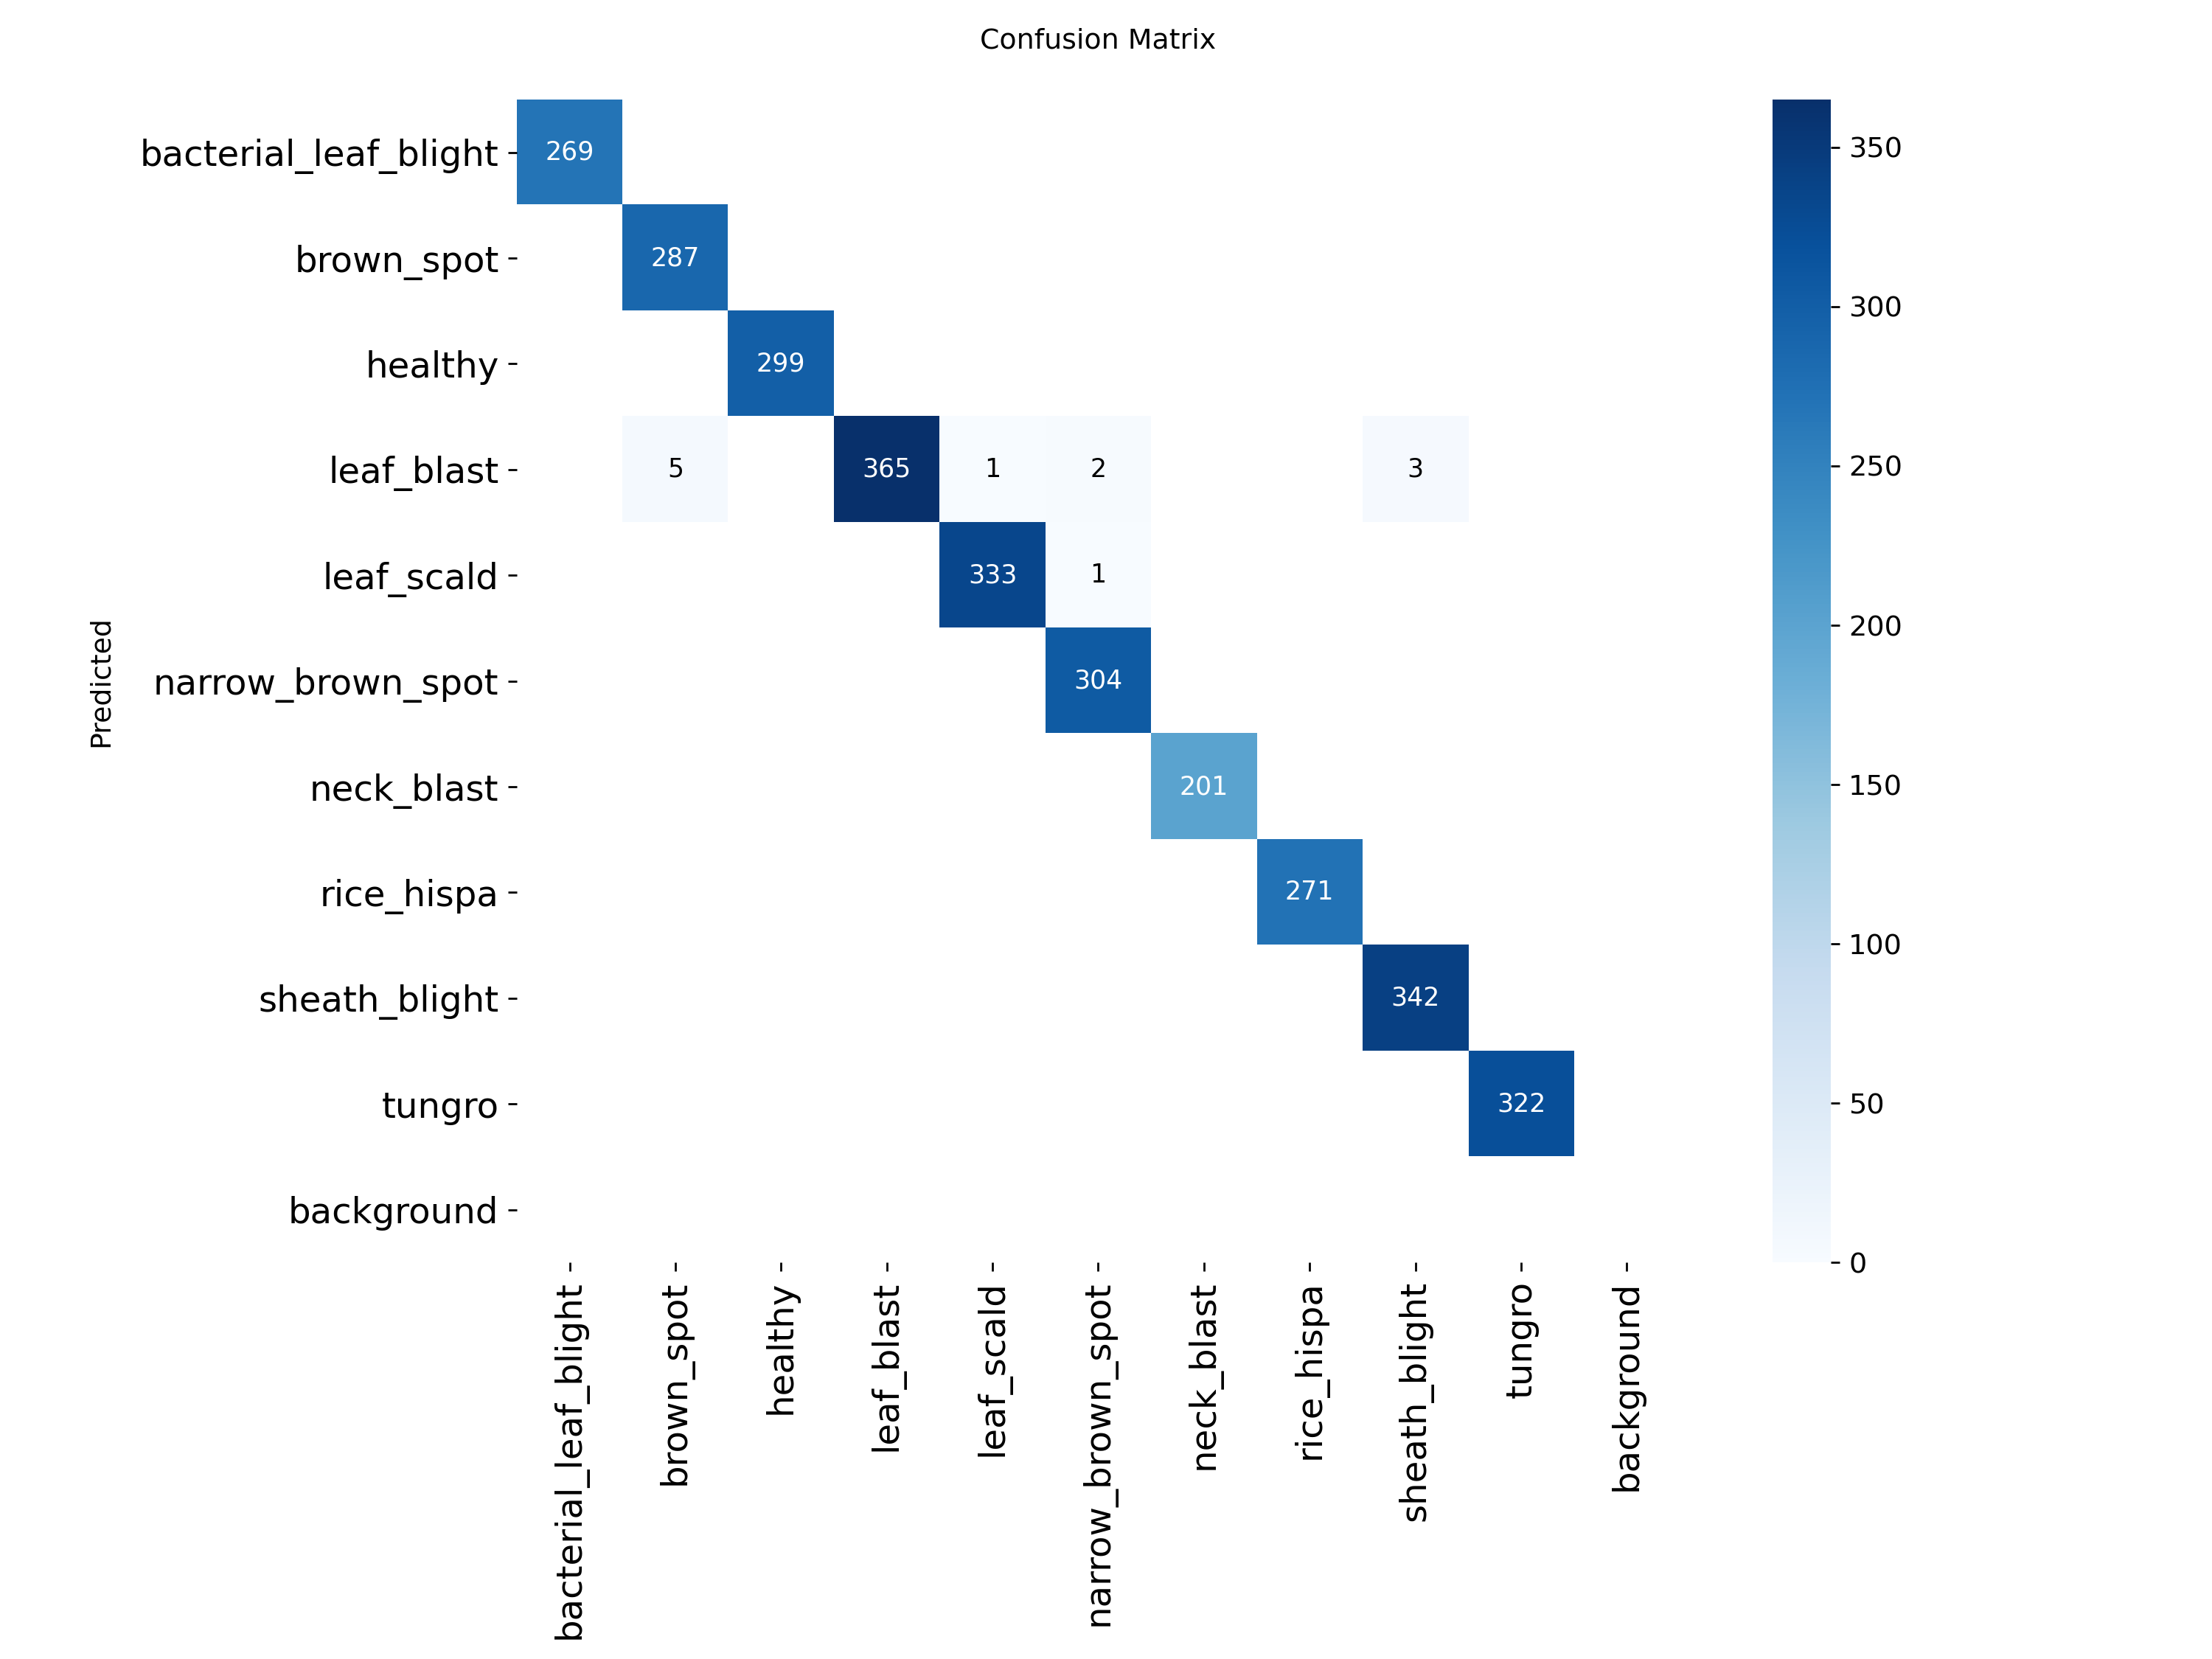

In [20]:
from IPython.display import Image, display

display(Image("/content/runs/classify/rice_disease_cls/v1/confusion_matrix.png"))

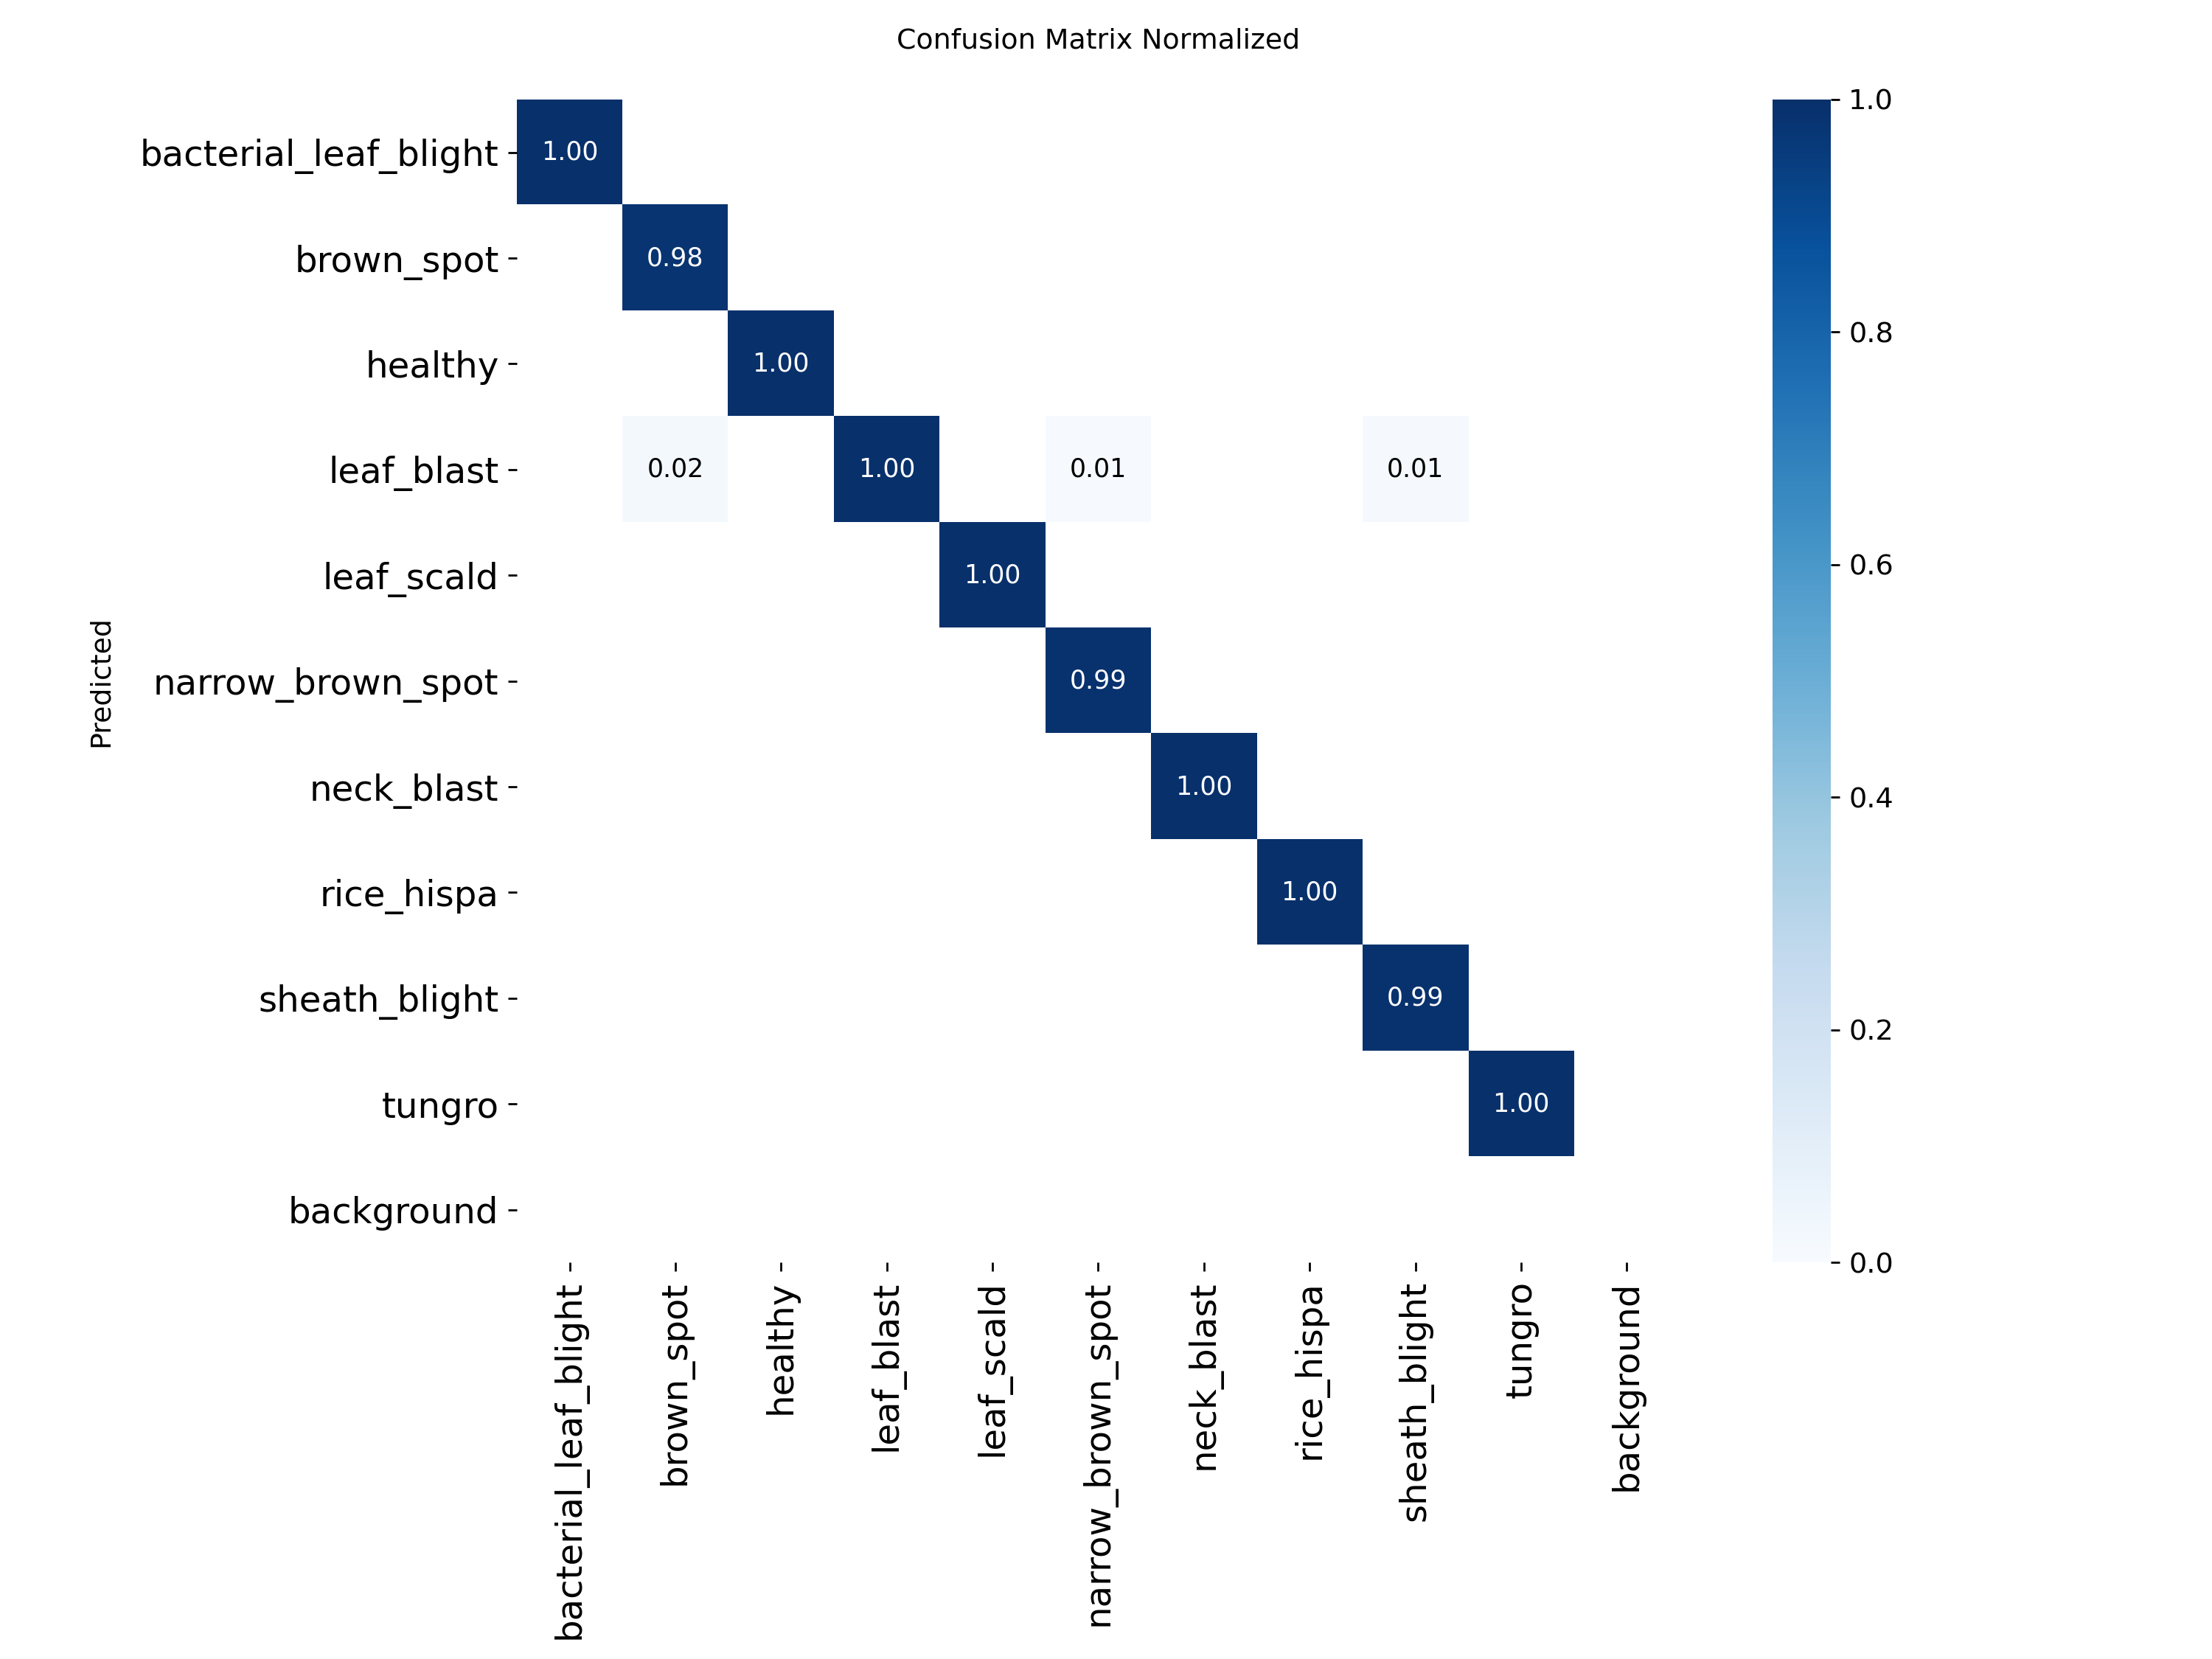

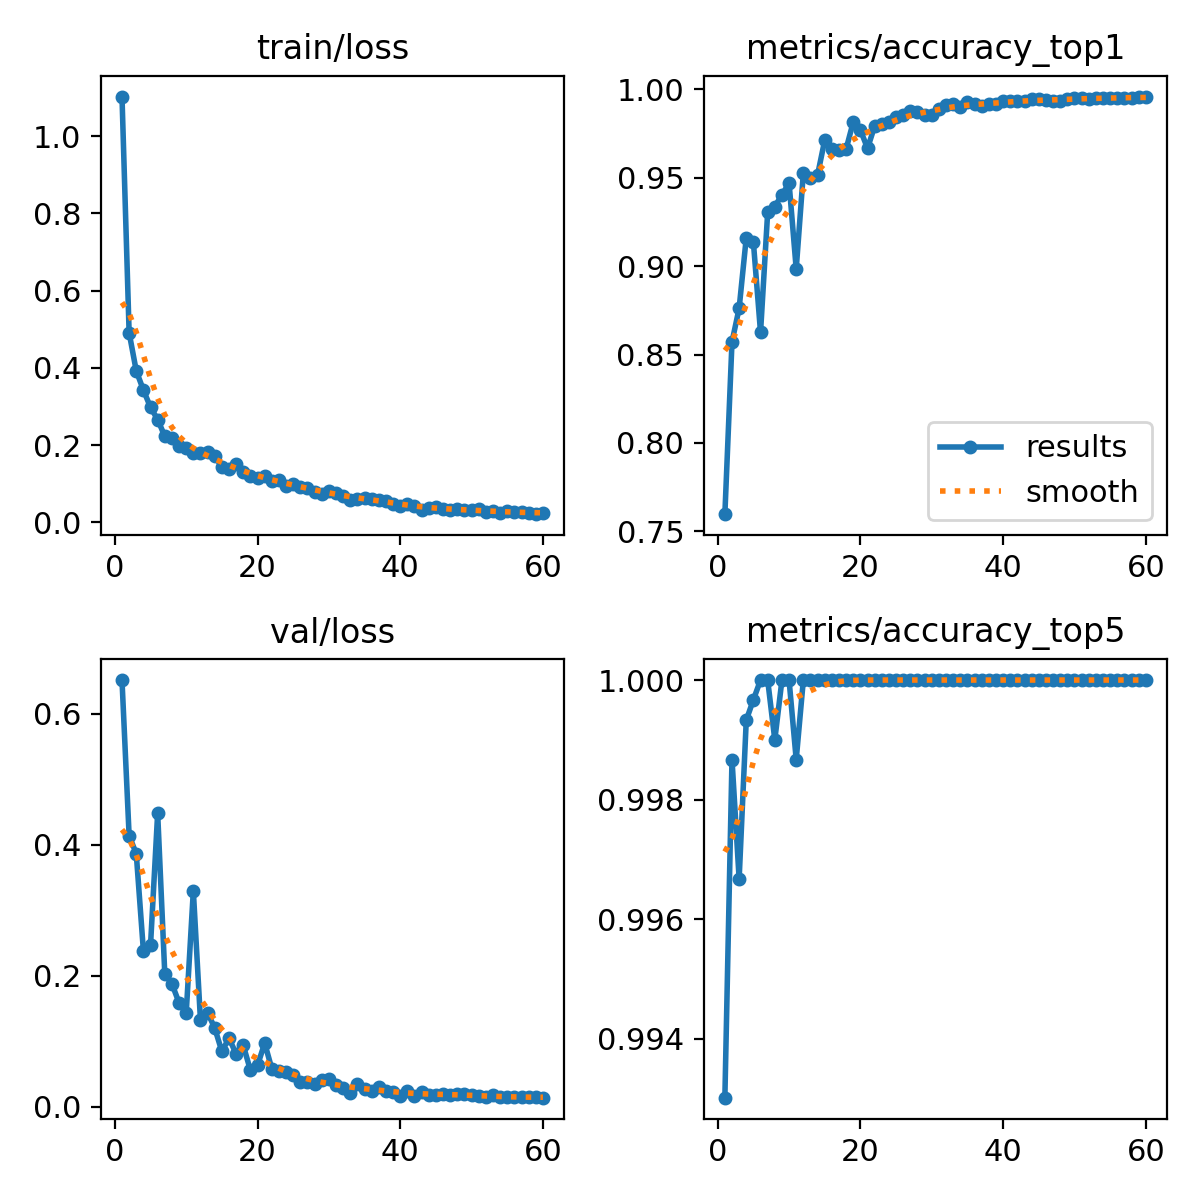

In [21]:
display(Image("/content/runs/classify/rice_disease_cls/v1/confusion_matrix_normalized.png"))  # percentages instead of raw counts — easier to read
display(Image("/content/runs/classify/rice_disease_cls/v1/results.png"))  # loss & accuracy curves over all epochs

# Backup all the files, weights, plots , logs

In [22]:
os.system("cp -r /content/runs/classify/rice_disease_cls /content/drive/MyDrive/rice_disease_cls_backup")
print("Backed up to Drive: /content/drive/MyDrive/rice_disease_cls_backup")


Backed up to Drive: /content/drive/MyDrive/rice_disease_cls_backup


In [23]:
BEST_WEIGHTS = "/content/runs/classify/rice_disease_cls/v1/weights/best.pt"
print(f"Best model saved at: {BEST_WEIGHTS}")

from google.colab import files
files.download(BEST_WEIGHTS)

Best model saved at: /content/runs/classify/rice_disease_cls/v1/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

testinf with an unknown image

In [ ]:
from ultralytics import YOLO

# If model is already in memory from training, skip this line.
# Otherwise reload it:
model = YOLO("/content/runs/classify/rice_disease_cls/v1/weights/best.pt")

# Upload a test image
from google.colab import files
uploaded = files.upload()  # pick an image from your computer

# Get the filename you just uploaded
image_path = list(uploaded.keys())[0]

# Run prediction
results = model.predict(image_path)
result = results[0]

# Print results
top1_idx = result.probs.top1
top1_conf = float(result.probs.top1conf)
disease_name = model.names[top1_idx]

print(f"Predicted Disease: {disease_name}")
print(f"Confidence: {top1_conf:.4f}")

# Show top-5 for more context
print("\nTop-5 predictions:")
for idx, conf in zip(result.probs.top5, result.probs.top5conf.tolist()):
    print(f"  {model.names[idx]}: {conf:.4f}")